In [1]:
import copy
import cupy as cp

import pickle
import inspect
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
from rich import progress
from scipy import constants

# from centrex_tlf import hamiltonian, states
from centrex_trajectories import (
    Coordinates,
    Gravity,
    PropagationOptions,
    PropagationType,
    Velocities,
    propagate_trajectories,
)
from centrex_trajectories.beamline_objects import (
    Bore,
    CircularAperture,
    ElectrostaticLensPolynomial,
    ElectrostaticQuadrupoleLens,
    RectangularAperture,
    Section,
)
from centrex_trajectories.particles import TlF
from centrex_trajectories.utils import (
    double_richards_symmetric,
    fit_stark_potential,
)
from centrex_trajectories.polynomials import Polynomial2D
from centrex_trajectories.visualization import plot_beamline
# from eigenshuffle import eigenshuffle_eigh


In [2]:
plt.rcParams.update({"font.size": 14})


In [3]:
class TaskSpeed(progress.ProgressColumn):
    def render(self, task):
        if task.speed is None:
            return ""
        elif task.speed >= 0.1:
            return f"{(task.speed or 0):.1f}/s"
        else:
            return f"{(1 / task.speed or 0):.1f} s/i"


# Setup
## Generate Stark Potentials

In [4]:
with open("fit_coeffs.pkl", "rb") as f:
    fit_coeffs = pickle.load(f)
fit_coeff_mF0 = fit_coeffs["mF0"]
fit_coeff_mF2 = fit_coeffs["mF2"]
fit_coeff_mF3 = fit_coeffs["mF3"]

## Beamline Setup

In [5]:
options = PropagationOptions(verbose=False, n_cores=24)
particle = TlF()
gravity = Gravity(0, -9.81 * particle.mass, 0)

# EQL parameters
L = 0.6
R = 1.75 * 25.4e-3 / 2
V = 28_000


# [NEW] don't limit DET aperture size, do post selection later
wx = 1
wy = 1

# conversion factors
in_to_m = 25.4e-3

n_nipples = 3

# beamline lengths
distance_lens_bbexit = 36 * in_to_m
lens_chamber_length = (24 + 5 / 8) * in_to_m
lens_reducer_flange = (7 / 8 + 3 + 1 / 8) * in_to_m
lens_electrode_length = L  # m
nipple_length = 39 * in_to_m
distance_det_center = 5.25 * in_to_m
lens_reducer_flange = (3 + 1 / 8 + 7 / 8) * in_to_m
bs_flange = 3 / 4 * in_to_m
rc_chamber_length_no_flanges = 10.5 * in_to_m
rc_chamber_center_from_bs_front = (16 + 3 / 8) * in_to_m
rc_aperture_from_center = 3.56 * in_to_m
rc_aperture_radius = 0.011



In [6]:
MEASURED_RES_PARAMS = [ 0.4056197,  -0.35732858,  2.2139628,   0.06165752]
amplitude = MEASURED_RES_PARAMS[0]
SIGMA = MEASURED_RES_PARAMS[2]*1e-3
OFFSET = MEASURED_RES_PARAMS[3]
R_MAX=10e-3

rs = np.linspace(0, R_MAX, 1000)
F_r = amplitude * np.exp(-(rs**2) / (2 * SIGMA**2)) + OFFSET

# 4. CRITICAL STEP: Apply the Jacobian radial weight (2 * pi * r)
# This prevents the center from overcrowding and accounts for the ring area
R_r = 2 * np.pi * rs * F_r

# 5. Normalize into a Cumulative Distribution Function (CDF)
pdf_r = R_r / np.trapz(R_r, rs)
cdf_r = np.cumsum(pdf_r)
cdf_r /= cdf_r[-1]  # Force the array to end exactly at 1.0

# 6. Transfer the lookup tables to the GPU
cp_cdf_r = cp.array(cdf_r)
cp_rs = cp.array(rs)

def position_init(n_trajectories):
    # 7. Generate uniform random numbers for Radius and Angle
    u_r = cp.random.rand(n_trajectories)
    u_theta = cp.random.rand(n_trajectories) * 2 * cp.pi

    # 8. Sample the Radius and convert to Cartesian
    sampled_r = cp.interp(u_r, cp_cdf_r, cp_rs)
    sampled_x = sampled_r * cp.cos(u_theta)
    sampled_y = sampled_r * cp.sin(u_theta)

    # (Optional) Initialize your Coordinates object here
    return Coordinates(sampled_x, sampled_y, cp.zeros(n_trajectories))

C:\Users\zhoup\AppData\Local\Temp\ipykernel_27040\1745079868.py:15: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pdf_r = R_r / np.trapz(R_r, rs)


In [7]:
potential_xy_coefficients = np.array(
    [
        [
            0.00000000e00,
            0.00000000e00,
            -1.85807316e-03,
            -3.68838654e-01,
            9.05179603e01,
            5.02802652e02,
            -2.33774653e05,
        ],
        [
            0.00000000e00,
            -4.01516882e03,
            -4.57787118e-02,
            -8.53726662e03,
            -9.44499189e03,
            5.34213172e08,
            2.04894221e07,
        ],
        [
            1.55556469e-02,
            -1.08269983e01,
            4.98195718e02,
            1.21401040e05,
            -6.62042908e06,
            -2.00043668e08,
            1.63384388e10,
        ],
        [
            4.95047018e-01,
            -8.94339785e03,
            1.44796476e04,
            -1.69855041e09,
            -6.86084354e07,
            -6.47064425e09,
            -2.57901217e04,
        ],
        [
            -1.83341406e02,
            4.73566410e04,
            2.21617329e06,
            -3.02270553e08,
            -7.46259863e09,
            -1.14022371e05,
            -3.74750620e05,
        ],
        [
            -1.83757741e03,
            5.34389645e08,
            -1.65987718e07,
            6.46968544e09,
            -2.13239592e04,
            -1.31548209e02,
            -7.07835673e00,
        ],
        [
            2.78503072e05,
            -4.15374780e07,
            -1.08606156e09,
            -1.22530620e05,
            -2.91966193e06,
            -3.60532824e01,
            -5.51716726e02,
        ],
    ]
)

args_double_richards = [
    np.float64(-0.2772285477882198), 
    np.float64(0.2772285477882198),
    0.0,
    1.0,
    np.float64(0.17549989486349324),
    np.float64(199.16917527732758),
    np.float64(3.3589614392622846),
]

signature = inspect.signature(double_richards_symmetric)
arg_names = [param.name for param in signature.parameters.values()]

potential_z = partial(
    double_richards_symmetric,
    **dict([(name, arg) for name, arg in zip(arg_names[1:], args_double_richards)]),
)

## Beamline Sections


In [8]:
fourK = Section(
    name="4K shield",
    objects=[CircularAperture(0, 0, 1.75 * in_to_m, in_to_m / 2)],
    start=0,
    stop=(1.75 + 0.25) * 0.0254,
    save_collisions=False,
    propagation_type=PropagationType.ballistic,
)
fourtyK = Section(
    name="40K shield",
    objects=[CircularAperture(0, 0, fourK.stop + 1.25 * in_to_m, in_to_m / 2)],
    start=fourK.stop,
    stop=fourK.stop + (1.25 + 0.25) * 0.0254,
    save_collisions=False,
    propagation_type=PropagationType.ballistic,
)
bbexit = Section(
    name="Beamsource Exit",
    objects=[CircularAperture(0, 0, fourtyK.stop + 2.5 * in_to_m, 2 * in_to_m)],
    start=fourtyK.stop,
    stop=fourtyK.stop + (2.5 + 0.75) * in_to_m,
    save_collisions=False,
    propagation_type=PropagationType.ballistic,
)
rc_entrance = Section(
    name="Rotational cooling entrance",
    objects=[
        CircularAperture(
            x=0,
            y=0,
            z=0.473 + 0.005,
            r=46.74*1e-3/2,
        )        
    ],
    start=0.473,
    stop=0.473 + 0.01,
    save_collisions=False,
    propagation_type=PropagationType.ballistic,
)
rc = Section(
    name="Rotational cooling",
    objects=[
        CircularAperture(
            x=0,
            y=0,
            z=0.678,
            r=rc_aperture_radius,
        )
    ],
    start=0.473,
    stop=0.720,
    save_collisions=False,
    propagation_type=PropagationType.ballistic,
)

lens_start = 1.10

lens_stop = 1.70
lens_middle = (lens_start + lens_stop) / 2

eql = ElectrostaticLensPolynomial(
    name="Electrostatic Lens",
    objects=[
        Bore(
            x=0,
            y=0,
            z=1.10,
            length=lens_electrode_length,
            radius=R,
        )
    ],
    start=lens_start,
    stop=lens_stop,
    V=V,
    R=R,
    save_collisions=False,
    potential_xy=Polynomial2D(kx=6, ky=6, coeffs=potential_xy_coefficients),
    potential_z=lambda z: potential_z(z - lens_middle),
)
det = Section(
    name="Detection",
    objects=[
        RectangularAperture(
            0,
            0,
            5.2-1.125*in_to_m,
            wx,
            wy,
        )
    ],
    start=5.0,
    stop=5.20,
    save_collisions=False,
    propagation_type=PropagationType.ballistic,
    force=None,
)


In [9]:
import gc

def lens_scan_function(
    origin: Coordinates,
    velocities: Velocities,
    voltage: float,
    length: float = 0.6,
    radius: float = 0.022225,
    stark_potential: npt.NDArray[np.float64] = fit_coeff_mF0,
    ideal_lens: bool = False,
):
    lens_start = bbexit.stop + distance_lens_bbexit + (lens_chamber_length - length) / 2
    lens_stop = lens_start + length
    lens_middle = (lens_start + lens_stop) / 2

    if voltage == 0:
        eql = Section(
            name="Electrostatic Lens",
            objects=[
                Bore(
                    x=0,
                    y=0,
                    z=lens_start,
                    length=length,
                    radius=radius,
                )
            ],
            start=lens_start,
            stop=lens_stop,
            save_collisions=False,
        )
    else:
        if ideal_lens:
            eql = ElectrostaticQuadrupoleLens(
                name="Electrostatic Lens",
                objects=[Bore(x=0, y=0, z=lens_start, length=length, radius=radius)],
                start=lens_start,
                stop=lens_stop,
                V=voltage,
                R=radius,
                save_collisions=False,
                stark_potential=stark_potential,
            )
        else:
            eql = ElectrostaticLensPolynomial(
                name="Electrostatic Lens",
                objects=[
                    Bore(
                        x=0,
                        y=0,
                        z=lens_start,
                        length=length,
                        radius=radius,
                    )
                ],
                start=lens_start,
                stop=lens_stop,
                V=voltage,
                R=radius,
                save_collisions=False,
                stark_potential=stark_potential,
                potential_xy=Polynomial2D(kx=6, ky=6, coeffs=potential_xy_coefficients),
                potential_z=lambda z: potential_z(z - lens_middle),
            )

    sections = [fourK, fourtyK, bbexit, rc_entrance, rc, eql, det]
    section_data, trajectories = propagate_trajectories(
        sections,
        origin,
        velocities,
        particle,
        force=gravity,
        options=options,
    )
    return section_data, trajectories, sections

def generate_dist_before_lens(    origin: Coordinates,
    velocities: Velocities,):

    sections = [fourK, fourtyK, bbexit, rc_entrance, rc]
    section_data, trajectories = propagate_trajectories(
        sections,
        origin,
        velocities,
        particle,
        force=gravity,
        options=options,
    )
    del section_data
    n = len(trajectories)                     # number of stored Trajectory objects

    # allocate the whole block once
    pos_arr = np.empty((n, 3), dtype=float)   # columns: x, y, z
    vel_arr = np.empty((n, 3), dtype=float)   # columns: vx, vy, vz

    for i, tr in enumerate(trajectories.values()):
        # fetch the last entry of each vector only once
        pos_arr[i, 0] = tr.x [-1]
        pos_arr[i, 1] = tr.y [-1]
        pos_arr[i, 2] = tr.z [-1]

        vel_arr[i, 0] = tr.vx[-1]
        vel_arr[i, 1] = tr.vy[-1]
        vel_arr[i, 2] = tr.vz[-1]

    last_positions  = Coordinates(pos_arr[:, 0], pos_arr[:, 1], pos_arr[:, 2])
    last_velocities = Velocities(vel_arr[:, 0], vel_arr[:, 1], vel_arr[:, 2])
    del trajectories
    gc.collect(1)   
    return last_positions, last_velocities

def lens_scan_function_with_input_before_lens(
    origin: Coordinates,
    velocities: Velocities,
    voltage: float,
    length: float = 0.6,
    radius: float = 0.022225,
    stark_potential: npt.NDArray[np.float64] = fit_coeff_mF0,
    ideal_lens: bool = False,
):
    lens_start = bbexit.stop + distance_lens_bbexit + (lens_chamber_length - length) / 2
    lens_stop = lens_start + length
    lens_middle = (lens_start + lens_stop) / 2

    if voltage == 0:
        eql = Section(
            name="Electrostatic Lens",
            objects=[
                Bore(
                    x=0,
                    y=0,
                    z=lens_start,
                    length=length,
                    radius=radius,
                )
            ],
            start=lens_start,
            stop=lens_stop,
            save_collisions=False,
        )
    else:
        if ideal_lens:
            eql = ElectrostaticQuadrupoleLens(
                name="Electrostatic Lens",
                objects=[Bore(x=0, y=0, z=lens_start, length=length, radius=radius)],
                start=lens_start,
                stop=lens_stop,
                V=voltage,
                R=radius,
                save_collisions=False,
                stark_potential=stark_potential,
            )
        else:
            eql = ElectrostaticLensPolynomial(
                name="Electrostatic Lens",
                objects=[
                    Bore(
                        x=0,
                        y=0,
                        z=lens_start,
                        length=length,
                        radius=radius,
                    )
                ],
                start=lens_start,
                stop=lens_stop,
                V=voltage,
                R=radius,
                save_collisions=False,
                stark_potential=stark_potential,
                potential_xy=Polynomial2D(kx=6, ky=6, coeffs=potential_xy_coefficients),
                potential_z=lambda z: potential_z(z - lens_middle),
            )
    eql.save_collisions = False
    sections = [eql, det]
    # print(eql.save_collisions)
    # if eql.save_collisions:
    #     print(f"{eql.name} saves collisions.")
    section_data, trajectories = propagate_trajectories(
        sections,
        origin,
        velocities,
        particle,
        force=gravity,
        options=options,
    )
    return section_data, trajectories, sections
    # return None


# Scan

In [10]:
data = {}

voltages = (
    np.array(
        # [0.0, 10.0, 15.0, 20.0, 21.25, 22.5, 23.75, 25.0, 26.25, 27.5, 28.75, 30.0]
        [0, 20, 22.5, 26.25, 30]
    )
    * 1e3
)
distributions_str = ["gaussian"]
distribution_parameters = np.array([2.2]) * 1e-3

from pathlib import Path
root = Path("saved_trajectories_vz_184ms_mean")   # top-level folder

def generate_vz_distribution(n_trajectories: int, vz_mean: float = 160, vz_sigma: float = 17):
    vz = cp.random.randn(n_trajectories) * vz_sigma + vz_mean
    vz = vz[(vz > 100) & (vz < 300)]
    while len(vz) < n_trajectories:
        additional_vz = cp.random.randn(n_trajectories - len(vz)) * vz_sigma + vz_mean
        additional_vz = additional_vz[(additional_vz > 100) & (additional_vz < 300)]
        vz = cp.concatenate((vz, additional_vz))
    vz = vz[:n_trajectories]
    return vz
with progress.Progress(
    progress.TextColumn("[progress.description]{task.description}"),
    progress.BarColumn(),
    progress.TaskProgressColumn(),
    progress.MofNCompleteColumn(),
    progress.TimeElapsedColumn(),
    progress.TimeRemainingColumn(),
) as pb:
    
    # n_trajectories = 400_000_000
    n_trajectories = 40_000_000


    velocities = Velocities(
        vx=cp.random.randn(n_trajectories) * 39.4,
        vy=cp.random.randn(n_trajectories) * 39.4,
        vz=generate_vz_distribution(n_trajectories, vz_mean=184, vz_sigma=17)
    )


    t0 = pb.add_task("distribution", total=len(distributions_str))
    t1 = pb.add_task("parameters", total=len(distribution_parameters))
    t2 = pb.add_task("mF", total=1)
    t3 = pb.add_task("voltage", total=len(voltages))
    for idd, distribution_str in enumerate(distributions_str):
        for idp, distribution_parameter in enumerate(distribution_parameters):
            sigma_x = distribution_parameter
            sigma_y = distribution_parameter
            if distribution_str == "uniform":
                theta = 2 * cp.pi * cp.random.rand(n_trajectories)
                origin = Coordinates(
                    x=cp.cos(theta) * sigma_x * cp.sqrt(cp.random.rand(n_trajectories)),
                    y=cp.sin(theta) * sigma_y * cp.sqrt(cp.random.rand(n_trajectories)),
                    z=cp.zeros(n_trajectories),
                )
            elif distribution_str == "gaussian":
                if sigma_x != 2.2e-3:
                    origin = Coordinates(
                        x=sigma_x * cp.random.randn(n_trajectories),
                        y=sigma_y * cp.random.randn(n_trajectories),
                        z=cp.zeros(n_trajectories),
                    )
                else:
                    origin = position_init(n_trajectories)
            propagated_origin, propagated_velocities = generate_dist_before_lens(origin, velocities)
            for idx, (mf, stark_coeff) in enumerate(zip(["mF=0"], [fit_coeff_mF0])):
                for idy, voltage in enumerate(voltages):
                    dest_dir = root / str(mf) / str(distribution_str) / str(distribution_parameter)
                    dest_dir.mkdir(parents=True, exist_ok=True)   # create folders

                    # Full file path: saved_trajectories/k1/k2/k3/k4.pkl
                    file_path = dest_dir / f"{voltage}.pkl"

                    _v1, _trajectories, _v2 = lens_scan_function_with_input_before_lens(
                        propagated_origin,
                        propagated_velocities,
                        voltage,
                        length=lens_electrode_length,
                        stark_potential=stark_coeff,
                    )
                    # data.setdefault(mf, {}).setdefault(distribution_str, {}).setdefault(distribution_parameter, {})[voltage] = _trajectories
                                        # Pickle the object (obj[1]) to that file
                    with file_path.open("wb") as f:
                        pickle.dump(_trajectories, f, protocol=pickle.HIGHEST_PROTOCOL)
                    del _trajectories, _v1, _v2
                    gc.collect(1)   # run garbage collector to free memory

                    pb.update(task_id=t3, completed=idy + 1, refresh=True)
                pb.update(task_id=t2, completed=idx + 1, refresh=True)
                pb.update(task_id=t3, completed=0, refresh=True)
            pb.update(task_id=t1, completed=idp + 1, refresh=True)
            pb.update(task_id=t2, completed=0, refresh=True)
        pb.update(task_id=t0, completed=idd + 1, refresh=True)
        pb.update(task_id=t1, completed=0, refresh=True)


Output()

In [14]:
cp.get_default_memory_pool().free_all_blocks()

# Visualize

## mF=0 only

#### Post selection on aperture sizes

In [18]:
root = Path("saved_trajectories_vz_160ms_mean")   # top-level folder


In [19]:
from pathlib import Path
import os
import pickle
import shutil
class TaskSpeed(progress.ProgressColumn):
    def render(self, task):
        if task.speed is None:
            return ""
        elif task.speed >= 0.1:
            return f"{(task.speed or 0):.1f}/s"
        else:
            return f"{(1 / task.speed or 0):.1f} s/i"

# --- Define the file wrapper ---
class RichProgressFileWrapper:
    def __init__(self, file_obj, progress, task_id):
        self.file_obj = file_obj
        self.progress = progress
        self.task_id = task_id

    def read(self, size=-1):
        """Read bytes and update the progress bar."""
        chunk = self.file_obj.read(size)
        self.progress.update(self.task_id, advance=len(chunk))
        return chunk

    def __getattr__(self, name):
        """Delegate other attribute access to the original file object."""
        return getattr(self.file_obj, name)
nr_survived = {}
aperture_size_xs = np.array([25]) * 1e-3
aperture_size_ys = np.array([10]) * 1e-3

def process_data_chunk(data_chunk):

    return None
nr_survived = {}
# root = Path("saved_trajectories_vz_170ms_mean")   # top-level folder
with progress.Progress(
        progress.TextColumn("[progress.description]{task.description}"),
        progress.BarColumn(bar_width=None),
        progress.TaskProgressColumn(),
        progress.MofNCompleteColumn(),
        progress.TimeElapsedColumn(),
        progress.TimeRemainingColumn(),
) as pb:
    all_dirs = list(root.glob("**/*.pkl"))
    t1 = pb.add_task(
        "Processing data",
        total=len(all_dirs),  # We don't know the total number of files in advance
        speed=TaskSpeed(),
    )
    t2 = pb.add_task(
        "aperture-x",
        total=len(aperture_size_xs),  # Number of aperture sizes in x
        speed=TaskSpeed(),
    )
    t3 = pb.add_task(
        "aperture-y",
        total=len(aperture_size_ys),  # Number of aperture sizes in y
        speed=TaskSpeed(),
    )
    task_id = None
    # The `glob` method is perfect for this.
    for file_path in all_dirs:
        path_parts = file_path.parts
        
        # Reconstruct the keys from the file path
        k1 = path_parts[-4] # voltage
        k2 = path_parts[-3] # parameter
        k3 = path_parts[-2] # distribution
        k4 = file_path.stem # mF
        # --- This is the core logic ---
        # 1. READ one file
        file_size = os.path.getsize(file_path)
        if task_id is not None:
            pb.remove_task(task_id)
        task_id = pb.add_task("Loading pickle", total=file_size)
        with file_path.open("rb") as f:
            wrapped_f = RichProgressFileWrapper(f, pb, task_id)
            trajectories = pickle.load(wrapped_f)

        for aperture_size_x in aperture_size_xs:     # ❺ aperture-x
            for aperture_size_y in aperture_size_ys: # ❻ aperture-y
                _nr_survived = 0
                for t in trajectories:
                    end = trajectories[t].coordinates[-1]
                    if (abs(end.x) < aperture_size_x / 2 and
                        abs(end.y) < aperture_size_y / 2):
                        _nr_survived += 1

                nr_survived \
                    .setdefault(k1, {}) \
                    .setdefault(k2, {}) \
                    .setdefault(k3, {}) \
                    .setdefault(k4, {}) \
                    .setdefault(aperture_size_x, {})[aperture_size_y] = _nr_survived
                pb.advance(t3, 1)
            pb.update(task_id=t3, completed=0, refresh=True)
            pb.advance(t2, 1)
        pb.advance(t1, 1)
        pb.update(task_id=t2, completed=0, refresh=True)
        del trajectories
        




Output()

In [20]:
from uncertainties import ufloat
gains = {}
for mf, data1 in nr_survived.items():
    for dist, data2 in data1.items():
        for param, data3 in data2.items():
            for volt, data4 in data3.items():
                for aperture_size_x, data5 in data4.items():
                    for aperture_size_y, _nr_survived in data5.items():
                        _gains = _nr_survived / data3['0.0'][aperture_size_x][aperture_size_y]
                        _gains_error = _gains * np.sqrt(1 / _nr_survived + 1 / data3['0.0'][aperture_size_x][aperture_size_y])
                        param = float(param) if isinstance(param, str) else param
                        volt = float(volt) if isinstance(volt, str) else volt
                        gains.setdefault(mf, {})\
                             .setdefault(aperture_size_x, {})\
                             .setdefault(aperture_size_y, {})\
                             .setdefault(dist, {})\
                             .setdefault(param, {})\
                             [volt]\
                              = ufloat(_gains, _gains_error)

[ 0.   20.   22.5  26.25 30.  ]
[1.0, 11.99687825182102, 14.998959417273673, 11.34859521331946, 6.527575442247659]
[0.04561979233461597, 0.4028023144384851, 0.49970620194315574, 0.3818722818907907, 0.22612147747833417]


C:\Users\zhoup\AppData\Local\Temp\ipykernel_6684\1633589187.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()


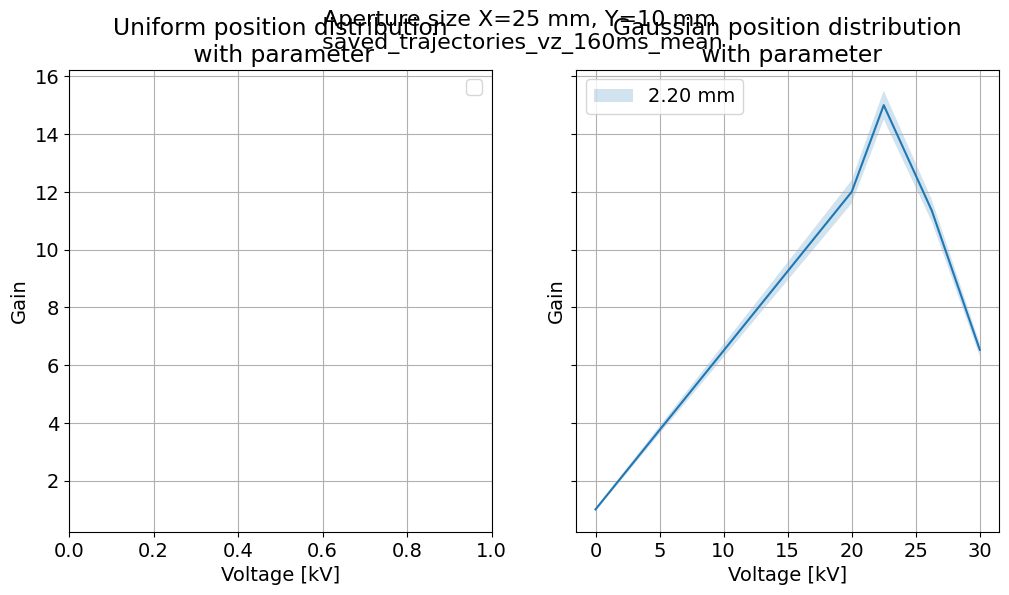

In [21]:
for aperture_size_x, data1 in gains['mF=0'].items():
    for aperture_size_y, data2 in data1.items():
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
        fig.suptitle(f"Aperture size X={aperture_size_x*1000:.0f} mm, Y={aperture_size_y*1000:.0f} mm\n {root}", fontsize=16)

        ax1.set_title("Uniform position distribution\n with parameter")
        ax2.set_title("Gaussian position distribution\n with parameter")

        for param, data4 in data2['gaussian'].items():
            ax2.fill_between(
                np.fromiter(data4.keys(), dtype=np.float64)/1000,
                np.array([g.n for g in data4.values()]) + np.array([g.s for g in data4.values()]),
                np.array([g.n for g in data4.values()]) - np.array([g.s for g in data4.values()]),
                alpha=0.2,
                label=f"{param*1000:.2f} mm",
            )
            ax2.plot(
                np.fromiter(data4.keys(), dtype=np.float64)/1000,
                [g.n for g in data4.values()],
            )
            print(np.fromiter(data4.keys(), dtype=np.float64)/1000)
            print([g.n for g in data4.values()])
            print([g.s for g in data4.values()])
        ax1.grid()
        ax2.grid()
        # ax1.set_ylim(0, 15)
        ax1.set_xlabel("Voltage [kV]")
        ax2.set_xlabel("Voltage [kV]")
        ax1.set_ylabel("Gain")
        ax2.set_ylabel("Gain")
        ax1.legend()
        ax2.legend()        